In [ ]:
%load_ext autoreload
%autoreload 2
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.loading import *
from src.plotting import *
from src.binned_alanysis import *``
from src.saving import *

In [2]:
gpm_stats = load_gpm_feature_stats(only_complete=False)

In [5]:
gpm_stats['is_complete'].sum()/gpm_stats['is_complete'].shape[0]

0.685946962587288

In [6]:
combined_feature_data = combined_feature_data = load_combined_features()

Loading combined features from /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/data/combined_features.pkl...


In [7]:
model_names = list(combined_feature_data.keys())
# Start from the active matplotlib color cycle
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {}
cycle_index = 0
for model_name in model_names:
    if model_name == "GPM":
        model_colors[model_name] = "black"
    else:
        model_colors[model_name] = color_cycle[cycle_index % len(color_cycle)]
        cycle_index += 1

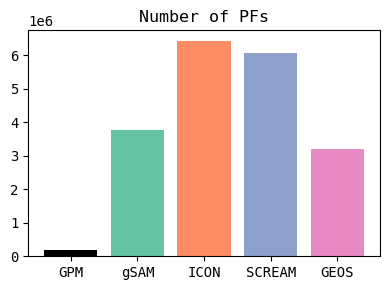

In [8]:
counts = {}

for model_name, df in combined_feature_data.items():
    counts[model_name] = df['is_complete'].sum()

models = list(counts.keys())
values = list(counts.values())
color_list = [model_colors[m] for m in models]

fig, ax = plt.subplots(figsize=(4,3))
ax.bar(models, values, color=color_list)
# ax.set_ylabel("99th percentile of max_precip")
ax.set_title("Number of PFs")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()